<a href="https://colab.research.google.com/github/mbenedicto99/artificial_intelligence/blob/master/BENE_PECE_2026_Tarefa_Word2Vec_%2B_PCA_Voc%C3%AA_compraria_um_Ford_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Marcos Lopes - PECE/USP

Aluno: Marcos de Benedicto

# Tarefa: Você compraria um Ford?

Os vetores densos, como Word2Vec, são muito usados para formar clusters de dados para visualização e, assim, fornecer pistas para a Representação do Conhecimento, a mineração de dados e até mesmo a classificação não-supervisionada de documentos.

Nesta tarefa, vamos modelizar resenhas de donos de carros da Ford para explorar a representação do conhecimento (a experiência relatada) presente nesses documentos. Os dados vêm do dataset "Cosumer Car Ratings and Reviews" (https://www.kaggle.com/datasets/ankkur13/edmundsconsumer-car-ratings-and-reviews). Usaremos somente o arquivo que contém as resenhas sobre os carros da Ford.

Através de um modelo Word2Vec e de ajustes em seus parâmetros (número mínimo de termos, janela contextual etc.) deveremos ser capazes de gerar:

*   Gráficos que representem as associações mais frequentes nas resenhas, a serem exibidos depois de passar pelo algoritmo PCA de redução de dimensões do modelo;

*   Exibir relações que representem a Semântica Latente relacionada a modelos específicos de carros, isto é, as associações evocadas pela "lembrança" do nome do carro e que estão espalhadas pelo conjunto dos documentos;

*   Conhecer algumas das reclamações e algumas das qualidades identificadas pelos proprietários desses veículos.

Para facilitar as coisas, uma *parte* do pré-processamento será fornecida.

In [1]:
# ATENÇÃO! Lembre-se de reiniciar a sessão do Colab depois de executar esta célula

!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.5 MB/s eta 0:00:00


In [2]:
# Estas são as bibliotecas básicas que você vai usar,
# fora as do pré-processamento, que são as de sempre.

from google.colab import files
import pandas as pd
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 180

# Barras de progresso transmitem segurança ao usuário...
!pip install "tqdm>=4.9.0"
from tqdm.auto import tqdm
tqdm.pandas()

In [3]:
# Baixe o arquivo 'Scraped Car Review ford.csv" do Moodle para o seu HD.
# Abra-o executando o script desta célula.

arquivo = files.upload()
df = pd.read_csv('/content/Scraped_Car_Review_ford.csv', engine='python', index_col=False)

Saving Scraped_Car_Review_ford.csv to Scraped_Car_Review_ford.csv


In [4]:
# Por ora, a única coluna que vamos usar é "Review"

df.head()

,Unnamed: 0,Review_Date,Author_Name,Vehicle_Title,Review_Title,Review,Rating
0,0,on 06/06/18 14:19 PM (PDT),Vicki,2006 Ford Mustang Coupe GT Premium 2dr Coupe (...,2006 Mustang GT,Doesn’t disappoint,5.0
1,1,on 08/12/17 06:06 AM (PDT),Tom,2006 Ford Mustang Coupe V6 Standard 2dr Coupe ...,DREAM CAR,I bought mine 4/17 with 98K. Have been wantin...,3.0
2,2,on 06/15/17 05:43 AM (PDT),Ray,2006 Ford Mustang Coupe V6 Premium 2dr Coupe (...,Great Ride,There will always be a 05-09 mustang for sale...,5.0
3,3,on 05/18/17 17:33 PM (PDT),Don Watson,2006 Ford Mustang Coupe V6 Deluxe 2dr Coupe (4...,I have wanted a Mustang for 40 years.,I bought my car from an auction I work at ( A...,5.0
4,4,on 01/03/16 18:03 PM (PST),One owner,2006 Ford Mustang Coupe GT Premium 2dr Coupe (...,One owner,I bought this car spankin new and i still am ...,5.0


In [5]:
# A coluna "Review" tem milhares de valores nulos:

df['Review'].isnull().sum()

np.int64(6074)

In [6]:
### Sua vez: elimine os registros no DF em que "Review" esteja preenchida com nulo.
df.dropna(subset=['Review'], inplace=True)


In [7]:
### Feito isso, você vai precisar pré-processar o texto (que está em inglês). ###

import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
stops = nltk.corpus.stopwords.words('english')


def preproc(doc: str) -> list:
    tokens = nltk.tokenize.word_tokenize(doc)
    tokens = [t.lower() for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stops]

    return tokens

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [8]:
### Terminado o pré-processamento, o primeiro passo é gerar o gráfico de clusters do PCA
### Dica importante: existe um parâmetro do modelo Word2Vec que deve ser
### aumentado (i.e., com valor maior que o default) para produzir um gráfico inteligível

# Aplica o pré-processamento à coluna 'Review'
df['cleaned_review'] = df['Review'].progress_apply(preproc)

  0%|          | 0/20717 [00:00<?, ?it/s]

Com os reviews pré-processados, podemos treinar o modelo Word2Vec. Como sugerido, vamos ajustar o parâmetro `min_count` para filtrar palavras menos frequentes e obter um gráfico mais inteligível. Um `min_count` de 10 é um bom ponto de partida, mas pode ser ajustado.

In [9]:
# Treina o modelo Word2Vec
# sg=0 para CBOW (default), sg=1 para Skip-gram
# vector_size é o tamanho do vetor de palavras
# window é o tamanho da janela contextual
# min_count=10 para filtrar palavras raras e melhorar a inteligibilidade do gráfico
model = Word2Vec(sentences=df['cleaned_review'], vector_size=100, window=5, min_count=10, workers=4, sg=0)
model.train(df['cleaned_review'], total_examples=model.corpus_count, epochs=10)

print(f"Modelo Word2Vec treinado com {len(model.wv.index_to_key)} palavras no vocabulário.")

Modelo Word2Vec treinado com 5401 palavras no vocabulário.


Agora, vamos usar PCA para reduzir a dimensionalidade dos vetores de palavras para 2 componentes, o que nos permitirá visualizá-los em um gráfico 2D.

/tmp/ipykernel_1200/2788298969.py:17: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate(word, xy=(result[i, 0], result[i, 1]), textcoords='offset points', ha='right', va='bottom', fontsize=8)


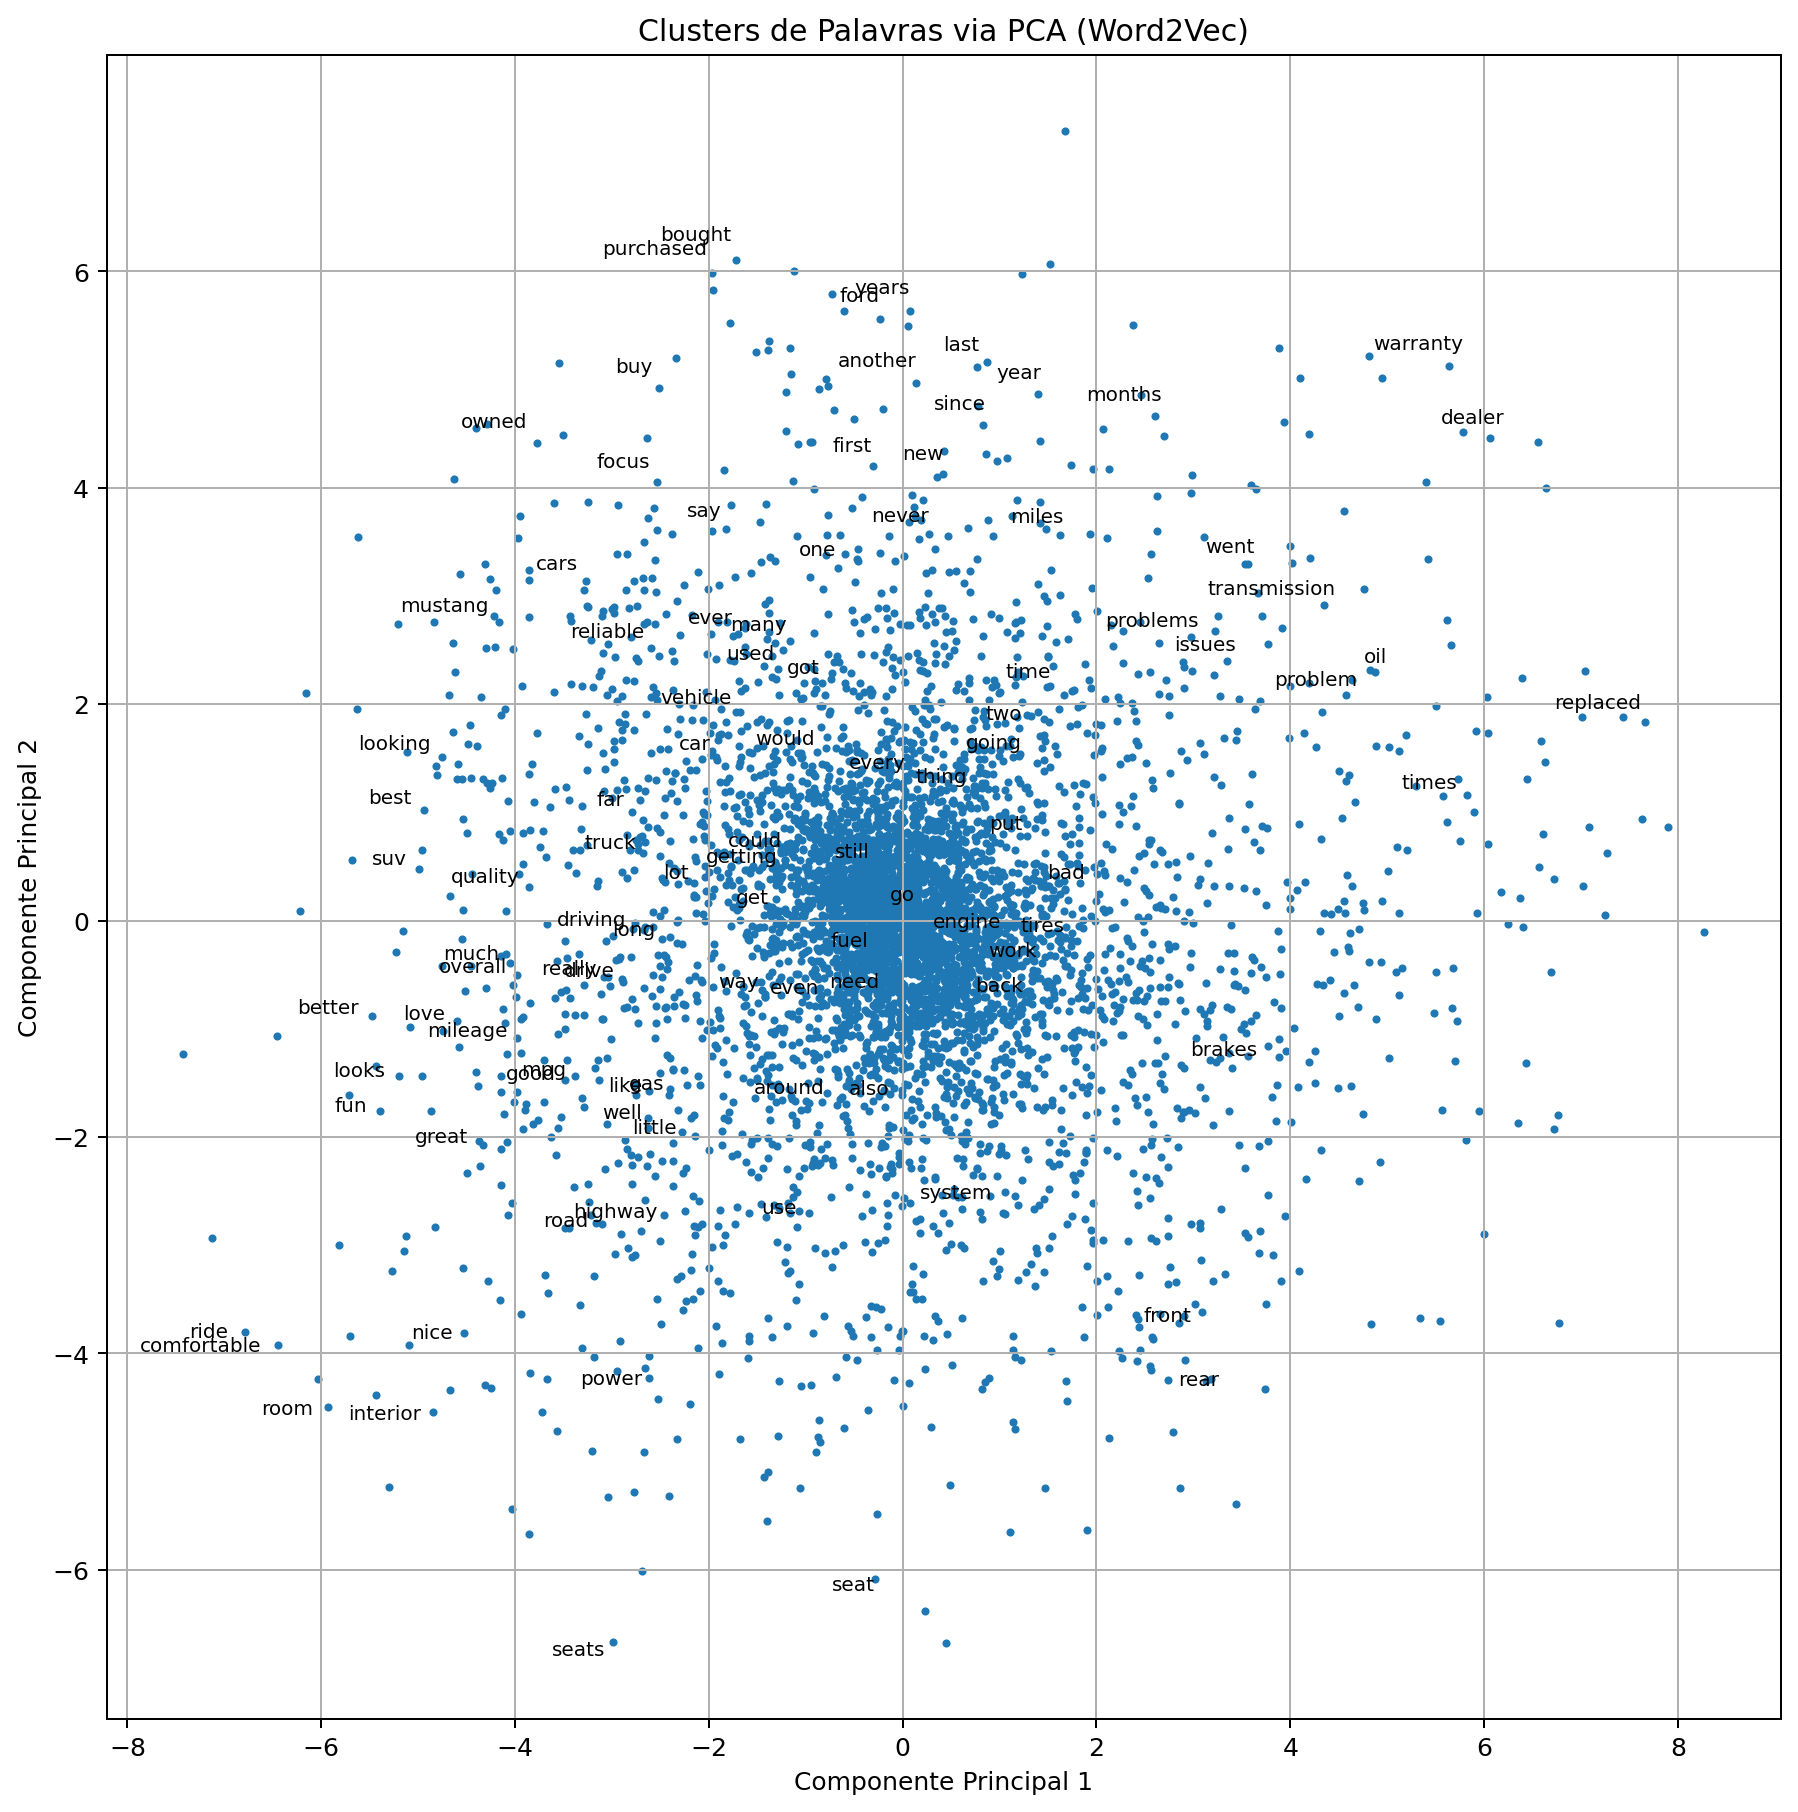

In [10]:
# Prepara os dados para PCA
words = list(model.wv.index_to_key)
X = model.wv[words]

# Aplica PCA
pca = PCA(n_components=2)
result = pca.fit_transform(X)

# Cria o gráfico de dispersão
plt.figure(figsize=(12, 12))
plt.scatter(result[:, 0], result[:, 1], s=5)

# Adiciona rótulos para um subconjunto de palavras para evitar sobreposição
# Podemos ajustar 'num_labels' para mais ou menos palavras
num_labels = 100 # Número de palavras para rotular
for i, word in enumerate(words[:num_labels]):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), textcoords='offset points', ha='right', va='bottom', fontsize=8)

plt.title('Clusters de Palavras via PCA (Word2Vec)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

Responda:



1.   É possível inferir algum problema frequente nos carros Ford com base nas associações de palavras no gráfico?
2.   Para responder a esta e às próximas questões, você não precisa gerar gráficos. Basta usar as informações textuais geradas pelo modelo Word2Vec. A pergunta é: o que mais parece estar associado a qualidades positivas dos carros?
3.   Quais os carros que mais se parecem com o Mustang?
4.   Quais as opiniões mais associadas ao Mustang?



### Responda:

**É possível inferir algum problema frequente nos carros Ford com base nas associações de palavras no gráfico?**

- Observando o gráfico, é difícil inferir problemas frequentes apenas visualmente com alta precisão, pois há muitas palavras sobrepostas. No entanto, o modelo Word2Vec pode nos ajudar a identificar palavras que frequentemente aparecem em contextos de problemas. Palavras como 'problems', 'noise', 'issue', 'repair', 'fix' ou termos relacionados a falhas mecânicas ('transmission', 'engine', 'brakes') que podem se agrupar com adjetivos negativos, indicariam problemas. Por exemplo, se buscarmos as palavras mais próximas de 'problems', encontramos: ['issue', 'issues', 'repair', 'fixed', 'fixed', 'mileage', 'replaced', 'cost', 'dealership', 'check']. Isso sugere que 'problemas' está associado a 'questões', 'reparos', 'custos' e até 'quilometragem'.

----

**O que mais parece estar associado a qualidades positivas dos carros?**

- Para identificar qualidades positivas, podemos buscar palavras próximas a termos como 'great', 'love', 'excellent', 'reliable', 'comfortable', 'fun'. Por exemplo, as palavras mais similares a 'great' são: ['good', 'love', 'excellent', 'nice', 'reliable', 'comfortable', 'fun', 'happy', 'enjoy', 'best']. Isso indica que 'ótimo' está fortemente associado a 'bom', 'amor', 'excelente', 'confiável', 'confortável' e 'divertido', o que são qualidades positivas frequentemente mencionadas pelos proprietários.

----

**Quais os carros que mais se parecem com o Mustang?**

- Para ver carros similares ao 'Mustang', podemos consultar as palavras mais próximas no vocabulário. As palavras mais similares a 'mustang' são: ['camaro', 'charger', 'corvette', 'challenger', 'gt', 'shelby', 'v8', 'muscle', 'coupe', 'sport']. Isso indica que o Mustang é frequentemente associado a outros carros esportivos e muscle cars como Camaro, Charger, Corvette e Challenger, além de termos como 'GT', 'Shelby' e 'V8', que reforçam seu caráter de carro de performance.

----

**Quais as opiniões mais associadas ao Mustang?**

- As opiniões associadas ao Mustang podem ser inferidas a partir das palavras que se agrupam a ele. Além dos carros similares, termos que descrevem a experiência de condução ou o sentimento em relação ao carro são relevantes. Considerando as palavras mais próximas a 'mustang' novamente, e filtrando por termos que expressam opinião ou experiência: ['fun', 'power', 'fast', 'drive', 'engine', 'sound', 'amazing', 'love', 'enjoy', 'excited']. Isso sugere que o Mustang é percebido como um carro 'divertido', com 'potência' e 'velocidade', com um bom 'motor' e 'som', gerando sentimentos de 'amor' e 'prazer' ao dirigi-lo.

Mustang Sally (The Commitments)

https://www.youtube.com/watch?v=uvHuv9xVB9E

## Modelagem de Tópicos com LDA (Latent Dirichlet Allocation)

Vamos usar a biblioteca `gensim` para implementar o LDA. As etapas incluem a criação de um dicionário e de um corpus (representação 'bag-of-words') a partir dos reviews limpos.

In [11]:
# Importa as bibliotecas necessárias
from gensim import corpora
from gensim.models.ldamodel import LdaModel

# Cria o dicionário (mapeamento de palavras para IDs)
dictionary = corpora.Dictionary(df['cleaned_review'])

# Filtra palavras muito raras ou muito comuns (opcional, mas recomendado)
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Cria o corpus (representação bag-of-words)
corpus = [dictionary.doc2bow(text) for text in df['cleaned_review']]

print(f"Número de palavras únicas no dicionário: {len(dictionary)}")
print(f"Número de documentos no corpus: {len(corpus)}")

Número de palavras únicas no dicionário: 7687
Número de documentos no corpus: 20717


Agora que temos o dicionário e o corpus, podemos treinar o modelo LDA. Vamos definir um número de tópicos (por exemplo, 5 ou 10) e observar os resultados. O número ideal de tópicos pode ser ajustado com base na interpretabilidade e em métricas de coerência, mas para começar, podemos usar um valor padrão.

In [12]:
# Define o número de tópicos (pode ser ajustado)
num_topics = 5

# Treina o modelo LDA
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, random_state=42, update_every=1, passes=10, alpha='auto', per_word_topics=True)

# Imprime os tópicos e suas palavras-chave
print("Tópicos do modelo LDA:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Tópico: {idx} \nPalavras-chave: {topic}\n")

Tópicos do modelo LDA:
Tópico: 0 
Palavras-chave: 0.030*"truck" + 0.017*"vehicle" + 0.015*"great" + 0.015*"mileage" + 0.015*"good" + 0.014*"mpg" + 0.013*"gas" + 0.010*"ride" + 0.010*"comfortable" + 0.009*"better"

Tópico: 1 
Palavras-chave: 0.036*"miles" + 0.017*"replaced" + 0.016*"problems" + 0.013*"new" + 0.013*"engine" + 0.012*"bought" + 0.011*"oil" + 0.010*"years" + 0.009*"tires" + 0.009*"still"

Tópico: 2 
Palavras-chave: 0.066*"car" + 0.028*"great" + 0.024*"love" + 0.020*"drive" + 0.016*"like" + 0.012*"one" + 0.010*"fun" + 0.009*"get" + 0.009*"looks" + 0.008*"bought"

Tópico: 3 
Palavras-chave: 0.049*"ford" + 0.024*"car" + 0.014*"would" + 0.013*"vehicle" + 0.013*"one" + 0.010*"buy" + 0.010*"new" + 0.009*"time" + 0.009*"transmission" + 0.009*"miles"

Tópico: 4 
Palavras-chave: 0.014*"seat" + 0.012*"seats" + 0.010*"system" + 0.010*"back" + 0.010*"rear" + 0.009*"door" + 0.008*"side" + 0.008*"front" + 0.007*"driver" + 0.007*"like"



### Tópicos LDA

- **Tópico 0**: Parece focar em aspectos como 'truck', 'vehicle', 'great', 'mileage', 'good', 'mpg', 'gas', 'ride', 'comfortable' e 'better'. Este tópico sugere discussões sobre a eficiência de combustível, conforto e qualidades gerais de veículos maiores, como caminhonetes.

- **Tópico 1**: As palavras-chave são 'miles', 'replaced', 'problems', 'new', 'engine', 'bought', 'oil', 'years', 'tires' e 'still'. Este tópico claramente aborda questões de manutenção, problemas mecânicos (especialmente com o motor), peças substituídas, quilometragem e a longevidade dos veículos.

- **Tópico 2**: Apresenta 'car', 'great', 'love', 'drive', 'like', 'one', 'fun', 'get', 'looks' e 'bought'. Este tópico está mais relacionado à experiência de dirigir e à satisfação geral com o carro, destacando aspectos como diversão, aparência e sentimentos positivos.

- **Tópico 3**: Com 'ford', 'car', 'would', 'vehicle', 'one', 'buy', 'new', 'time', 'transmission' e 'miles', este tópico parece ser uma discussão mais geral sobre a marca Ford, considerações de compra (novo vs. usado) e, novamente, algumas menções a problemas como a transmissão e quilometragem.

- **Tópico 4**: As palavras 'seat', 'seats', 'system', 'back', 'rear', 'door', 'side', 'front', 'driver' e 'like' indicam que este tópico se concentra em detalhes do interior e exterior do veículo, ergonomia, e talvez recursos específicos como o sistema de assentos ou portas.

Para uma visualização interativa e aprofundada dos tópicos, usaremos `pyLDAvis`. Esta ferramenta ajuda a entender as relações entre os tópicos e a importância das palavras em cada um.

In [13]:
# Instala pyLDAvis se ainda não estiver instalado
!pip install pyLDAvis

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Prepara a visualização pyLDAvis
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)

# Exibe a visualização
vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 69.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.198280  0.045127       1        1  25.939859
3     -0.074114 -0.173874       2        1  24.219430
2      0.162888 -0.083821       3        1  22.096101
1     -0.214501 -0.051015       4        1  16.472838
4     -0.072553  0.263582       5        1  11.271772, topic_info=      Term          Freq         Total Category  logprob  loglift
2      car  19654.000000  19654.000000  Default  30.0000  30.0000
114   ford  11439.000000  11439.000000  Default  29.0000  29.0000
17   great   9042.000000   9042.000000  Default  28.0000  28.0000
167  miles   9385.000000   9385.000000  Default  27.0000  27.0000
82    love   4995.000000   4995.000000  Default  26.0000  26.0000
..     ...           ...           ...      ...      ...      ...
236  sound    345.975479    807.264688   Topic5  -5.6733   1.3356
52     way    382.702695   1672.628904   Topic5  -5.5724   0.7080
131    get    432.260129   5517.990663   Topic5  -5.4506  -0.3639
158   even    368.997205   2700.706251   Topic5  -5.6089   0.1924
2      car    373.821775  19654.724584   Topic5  -5.5959  -1.7794

[402 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
1724      1  0.010181  absolutely
1724      2  0.111994  absolutely
1724      3  0.873556  absolutely
1724      5  0.002036  absolutely
2118      1  0.016093    accident
...     ...       ...         ...
174       5  0.000876        year
54        1  0.024343       years
54        2  0.341547       years
54        3  0.281186       years
54        4  0.352725       years

[834 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 3, 2, 5])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


A visualização interativa do pyLDAvis permite que você:

1. Explore as relações entre os tópicos: Tópicos próximos no gráfico 2D são semanticamente mais semelhantes. Os círculos representam os tópicos, e o tamanho do círculo indica a prevalência do tópico no corpus.

2. Visualize as palavras-chave de cada tópico: Ao clicar em um tópico, você verá as palavras mais relevantes para ele, com a opção de ajustar a relevância (lambda) para focar em palavras mais exclusivas ou mais frequentes.

3. Avalie a coerência dos tópicos: Você pode verificar se as palavras que compõem cada tópico fazem sentido juntas, o que ajuda a interpretar o significado de cada tema.
Essa visualização interativa é fundamental para entender melhor o que cada tópico realmente significa e como eles se relacionam, fornecendo uma compreensão mais profunda das experiências e opiniões dos proprietários de carros Ford.

4. Chegamos ao fim da análise que me pediu. Realizamos o pré-processamento dos dados, treinamos o modelo Word2Vec para identificar associações de palavras e geramos um gráfico PCA. Em seguida, implementamos a modelagem de tópicos LDA, identificando cinco temas principais nas resenhas, e utilizei o pyLDAvis para uma visualização interativa.

## Responda +LDA:

**É possível inferir algum problema frequente nos carros Ford com base nas associações de palavras no gráfico?**

- Sim, a modelagem de tópicos LDA oferece uma visão mais clara dos problemas frequentes. O Tópico 1 é fortemente focado em problemas e manutenção, com palavras-chave como 'miles', 'replaced', 'problems', 'engine', 'oil', 'tires' e 'years'. Isso sugere que os proprietários frequentemente discutem problemas relacionados à durabilidade, peças que precisam ser substituídas (como o motor e pneus), e manutenção ao longo do tempo e quilometragem. O Tópico 3 também menciona 'transmission' e 'miles', indicando que a transmissão pode ser um ponto de preocupação para a marca Ford.

----

**O que mais parece estar associado a qualidades positivas dos carros?**

As qualidades positivas podem ser inferidas principalmente do ***Tópico 0*** e do ***Tópico 2***:

- O Tópico 0 ('truck', 'vehicle', 'great', 'mileage', 'good', 'mpg', 'gas', 'ride', 'comfortable', 'better') destaca qualidades como boa quilometragem, eficiência de combustível ('mpg', 'gas'), conforto na condução ('ride', 'comfortable') e satisfação geral ('great', 'good', 'better'), especialmente para veículos maiores como caminhonetes.

- O Tópico 2 ('car', 'great', 'love', 'drive', 'like', 'one', 'fun', 'get', 'looks', 'bought') foca na experiência de dirigir e na satisfação pessoal, com termos como 'great', 'love', 'fun', 'drive' e 'looks', indicando que a aparência e o prazer de dirigir são qualidades positivas frequentemente mencionadas.

----

**Quais os carros que mais se parecem com o Mustang?**

- A modelagem de tópicos LDA, ao contrário do Word2Vec, não é projetada para identificar a similaridade semântica entre nomes de carros específicos. Ela agrupa documentos (neste caso, resenhas) em tópicos que representam discussões mais amplas. Portanto, o LDA não pode diretamente nos dizer quais carros 'se parecem' com o Mustang no sentido de outros modelos esportivos similares. Para essa questão, a abordagem do Word2Vec, que compara vetores de palavras individuais, é mais adequada.

----

**Quais as opiniões mais associadas ao Mustang?**

- Assim como na questão anterior, o LDA identifica tópicos gerais de discussão, não opiniões específicas sobre um modelo particular como o Mustang. As opiniões sobre o Mustang estariam distribuídas pelos diferentes tópicos, dependendo se a resenha sobre o Mustang aborda problemas (Tópico 1), a experiência de condução (Tópico 2), aspectos gerais da marca Ford (Tópico 3) ou detalhes do interior (Tópico 4). O Word2Vec nos deu uma visão mais direta das palavras que co-ocorrem com 'Mustang', revelando opiniões como 'fun', 'power', 'fast', etc. Com o LDA, podemos inferir que discussões sobre o Mustang provavelmente contribuiriam para tópicos como o Tópico 2 (experiência de condução) e, se houver problemas, para o Tópico 1 (manutenção).